# Experiment 7 — Feature-Augmented ICP vs Baseline

**Goal:** Compare three ICP variants on 10 seeds (clustered cloud, N=200):
1. **Baseline** — Gaussian matcher with sigma annealing, no features.
2. **Additive** — same matcher + `alpha * cos_sim` added to log-weights (`IdentityFeatureExtractor`).
3. **Append** — feature vectors appended to 3D coordinates before the KDTree; Gaussian weights from spatial distance only.

**Note:** `IdentityFeatureExtractor` returns `np.eye(N)` (D = N), so N=200 is used to keep memory tractable.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from icp import ICP, SigmaAnnealingCallback
from experiment_runner import MultiSeedSyntheticICPResult, fit_multi_seed
from matcher import GaussianMatcher, NearestNeighborMatcher
from feature_extractor import GeometricFeatureExtractor, IdentityFeatureExtractor
from visualization import ErrorMetricsVisualizer, TimeVisualizer
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS      = 20
MAX_ITER     = 200
TOL          = 1e-10
SIGMA_INIT   = 20.0
SIGMA_FINAL  = 1.0
K            = 10      # Number of points considered by the matcher
FE_K         = K       # Number of points considered by the feature extractor
ALPHA        = 5.0     # additive mode: cosine similarity weight (geometric)
BETA         = 1.0     # append mode: feature scale relative to spatial coords (geometric)
ALPHA_ID     = 5.0     # additive mode weight for IdentityFeatureExtractor
BETA_ID      = 1.0     # append mode scale for IdentityFeatureExtractor
CLOUD_STYLE  = "clustered"
N_POINTS     = 200
GEN_KWARGS   = dict(n=N_POINTS, noise_std=0.0, t_scale=8.0, style=CLOUD_STYLE)

## 1. ICP Factories

All three variants use identical sigma annealing. The two feature variants differ only in how the feature term is integrated into the E-step.

In [2]:
def make_baseline() -> ICP:
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K)
    annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_additive_icp() -> ICP:
    """GeometricFeatureExtractor, additive mode."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=GeometricFeatureExtractor(k=FE_K),
                               feature_mode='additive', alpha=ALPHA)
    annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_append_icp() -> ICP:
    """GeometricFeatureExtractor, append mode."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=GeometricFeatureExtractor(k=FE_K),
                               feature_mode='append', beta=BETA)
    annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_identity_additive_icp() -> ICP:
    """IdentityFeatureExtractor, additive mode — oracle correspondence signal."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=IdentityFeatureExtractor(),
                               feature_mode='additive', alpha=ALPHA_ID)
    annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

def make_identity_append_icp() -> ICP:
    """IdentityFeatureExtractor, append mode — oracle correspondence signal."""
    matcher  = GaussianMatcher(sigma=SIGMA_INIT, k=K,
                               feature_extractor=IdentityFeatureExtractor(),
                               feature_mode='append', beta=BETA_ID)
    annealer = SigmaAnnealingCallback(SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

## 2. Run ICP on several Seeds

In [3]:
print('Running baseline ICP ...')
results_b = fit_multi_seed(make_baseline(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running geometric additive ICP ...')
results_add = fit_multi_seed(make_additive_icp(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running geometric append ICP ...')
results_app = fit_multi_seed(make_append_icp(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running identity additive ICP ...')
results_id_add = fit_multi_seed(make_identity_additive_icp(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running identity append ICP ...')
results_id_app = fit_multi_seed(make_identity_append_icp(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

Running baseline ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:02<00:00,  6.73it/s]


Running geometric additive ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:16<00:00,  1.19it/s]


Running geometric append ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:12<00:00,  1.58it/s]


Running identity additive ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


Running identity append ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:02<00:00,  9.18it/s]


## 3. Convergence Curves — Mean ± Std across 10 Seeds

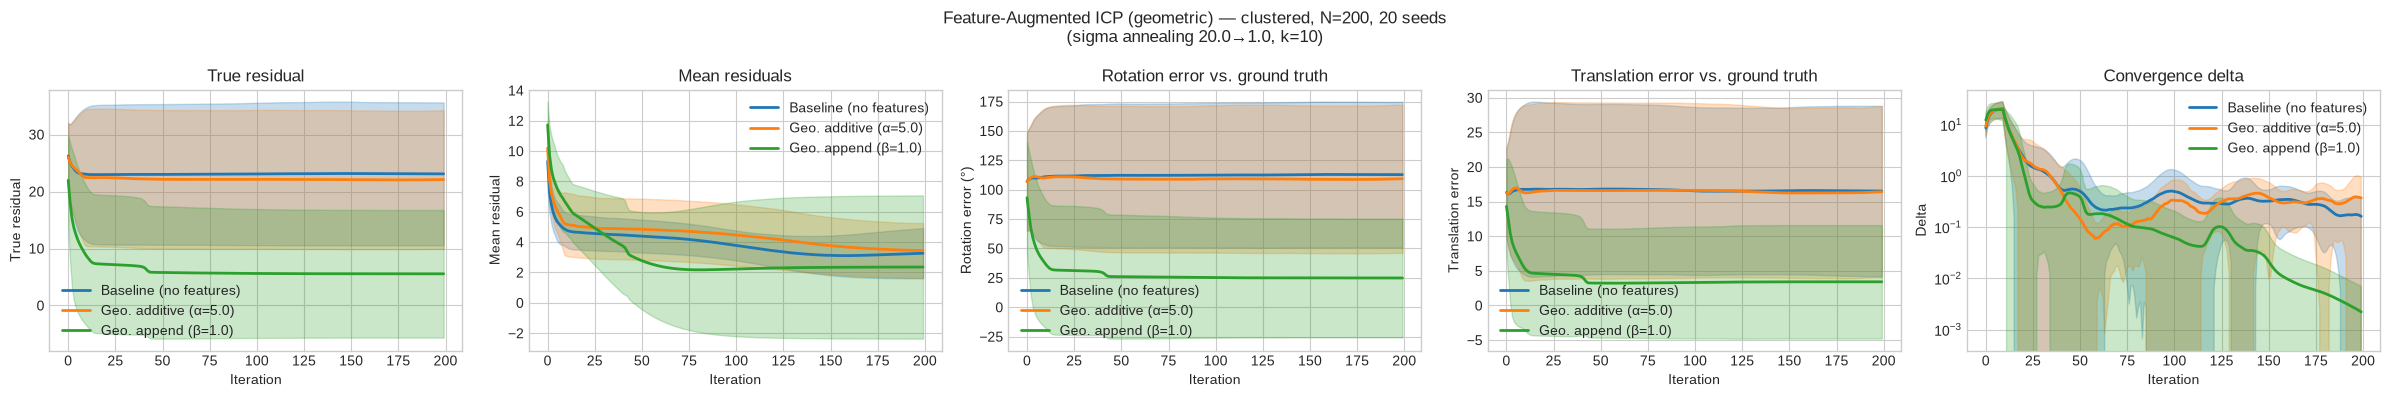

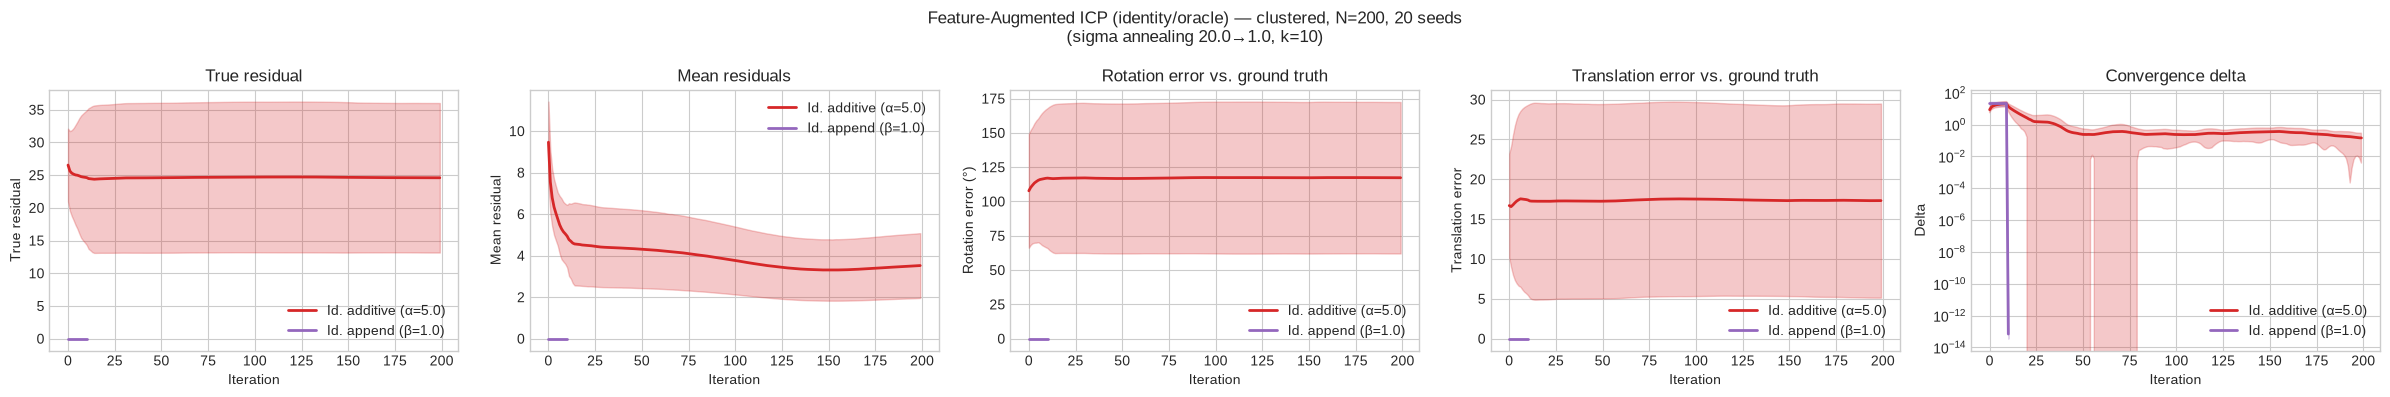

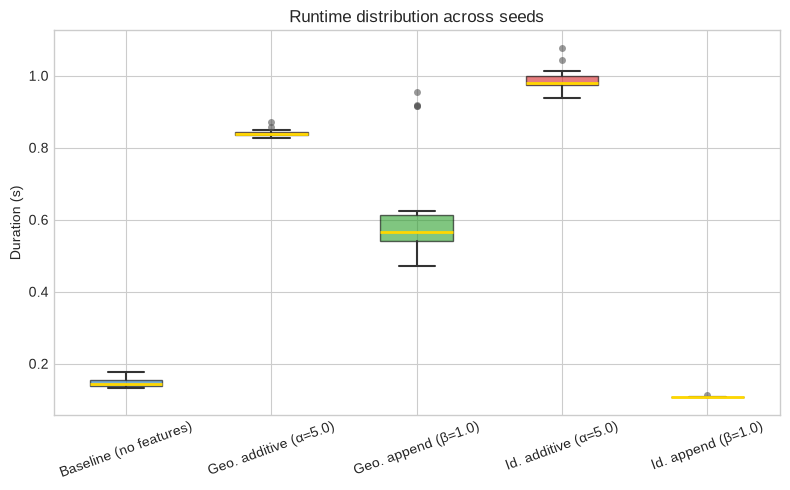

In [4]:
METHODS = [
    (results_b,       'Baseline (no features)',             'tab:blue'),
    (results_add,     f'Geo. additive (α={ALPHA})',         'tab:orange'),
    (results_app,     f'Geo. append (β={BETA})',            'tab:green'),
]
METHODS2 = [
    (results_id_add,  f'Id. additive (α={ALPHA_ID})',       'tab:red'),
    (results_id_app,  f'Id. append (β={BETA_ID})',          'tab:purple'),
]

fig1, axes1 = ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[m[0].results for m in METHODS],
    experiments_per_method=[m[0].experiments for m in METHODS],
    method_labels=[m[1] for m in METHODS],
    colors=[m[2] for m in METHODS],
)
fig1.suptitle(
    f'Feature-Augmented ICP (geometric) — {CLOUD_STYLE}, N={N_POINTS}, {N_SEEDS} seeds\n'
    f'(sigma annealing {SIGMA_INIT}→{SIGMA_FINAL}, k={K})'
)
fig1.tight_layout()
fig1.savefig('../results/7_feature_icp_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, axes2 = ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[m[0].results for m in METHODS2],
    experiments_per_method=[m[0].experiments for m in METHODS2],
    method_labels=[m[1] for m in METHODS2],
    colors=[m[2] for m in METHODS2],
)
fig2.suptitle(
    f'Feature-Augmented ICP (identity/oracle) — {CLOUD_STYLE}, N={N_POINTS}, {N_SEEDS} seeds\n'
    f'(sigma annealing {SIGMA_INIT}→{SIGMA_FINAL}, k={K})'
)
fig2.tight_layout()
fig2.savefig('../results/7_feature_icp_comparison_results_identity.png', dpi=150, bbox_inches='tight')
plt.show()

ALL_METHODS = METHODS + METHODS2
fig3, ax3 = plt.subplots(figsize=(8, 5))
TimeVisualizer.plot_duration_distribution(
    ax3,
    durations_per_method=[np.array([r.duration_s for r in m[0].results]) for m in ALL_METHODS],
    method_labels=[m[1] for m in ALL_METHODS],
    colors=[m[2] for m in ALL_METHODS],
)
ax3.tick_params(axis='x', rotation=20)
fig3.tight_layout()
fig3.savefig('../results/7_feature_icp_comparison_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Non-Additive Variants Repeated with `NearestNeighborMatcher`

`NearestNeighborMatcher` now also supports feature-augmented matching in **append**
mode: features (z-scored, scaled by `beta`) are appended to 3D coordinates before
the single-nearest-neighbor search, exactly like `GaussianMatcher`'s append mode
but keeping only the single closest joint candidate instead of a Gaussian-weighted
average. There is no additive analog for hard matching (additive mode perturbs
weights before a softmax over multiple candidates, which is meaningless with only
one candidate kept).

This repeats the three variants from Section 1/3 that do **not** use additive mode —
**Baseline**, **Geo. append**, and **Id. append** — swapping `GaussianMatcher` (soft,
sigma-annealed) for `NearestNeighborMatcher` (hard, no sigma).

In [5]:
def make_baseline_nn() -> ICP:
    """No features — pure nearest-neighbor hard matching."""
    return ICP(matcher=NearestNeighborMatcher(), max_iter=MAX_ITER, tol=TOL)

def make_append_nn() -> ICP:
    """GeometricFeatureExtractor, append mode."""
    matcher = NearestNeighborMatcher(feature_extractor=GeometricFeatureExtractor(k=FE_K), beta=BETA)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL)

def make_identity_append_nn() -> ICP:
    """IdentityFeatureExtractor, append mode — oracle correspondence signal."""
    matcher = NearestNeighborMatcher(feature_extractor=IdentityFeatureExtractor(), beta=BETA_ID)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL)


print('Running baseline NN ICP ...')
results_b_nn = fit_multi_seed(make_baseline_nn(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running geometric append NN ICP ...')
results_app_nn = fit_multi_seed(make_append_nn(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

print('Running identity append NN ICP ...')
results_id_app_nn = fit_multi_seed(make_identity_append_nn(), list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)

Running baseline NN ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:00<00:00, 59.69it/s]


Running geometric append NN ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:01<00:00, 14.48it/s]


Running identity append NN ICP ...


Solving 20 seeds: 100%|██████████| 20/20 [00:01<00:00, 14.57it/s]


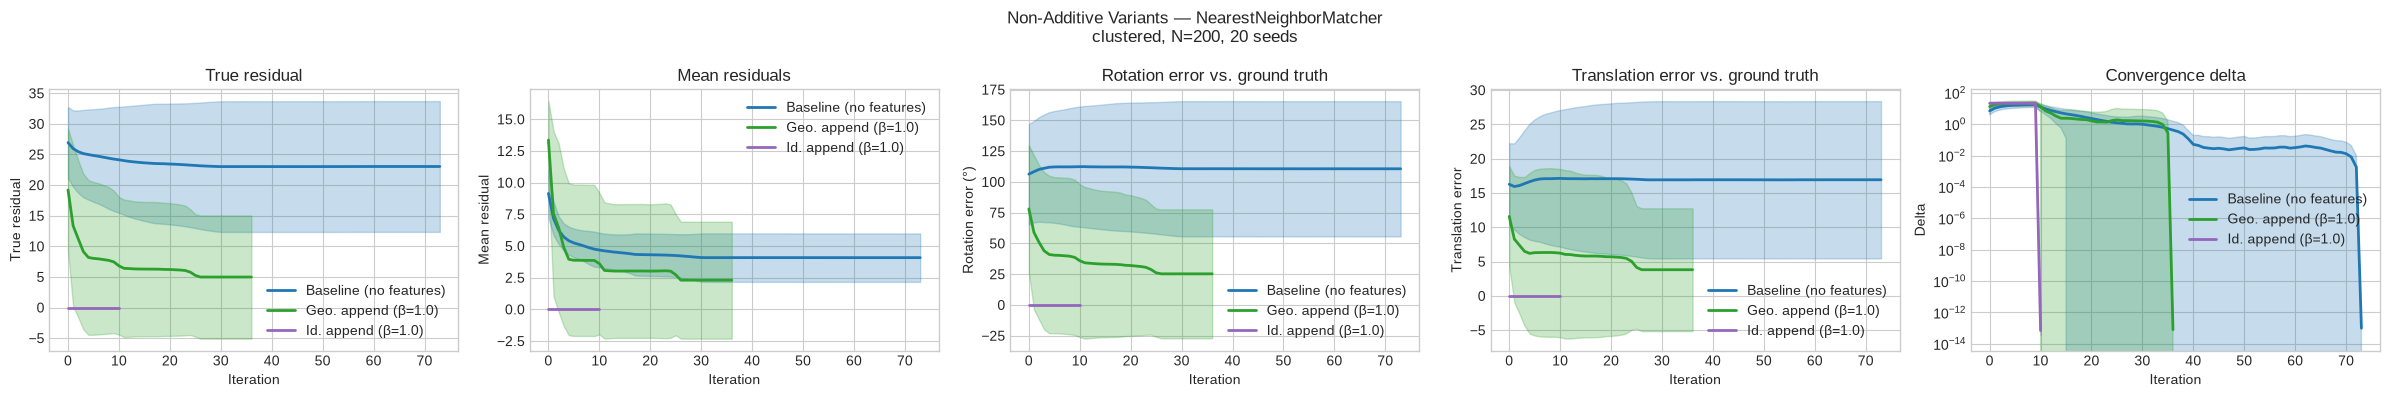

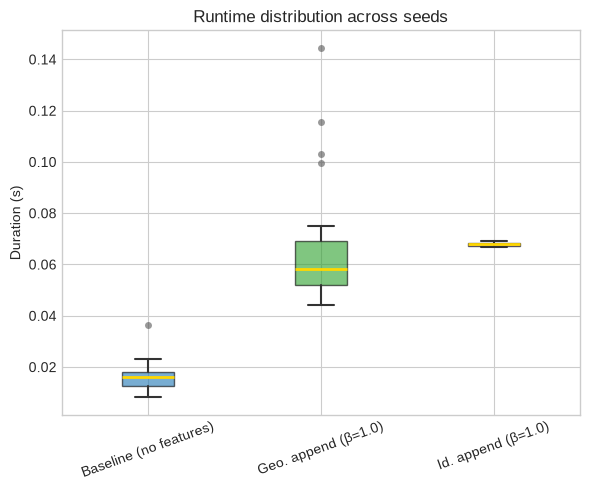

In [6]:
METHODS_NN = [
    (results_b_nn,      'Baseline (no features)',    'tab:blue'),
    (results_app_nn,    f'Geo. append (β={BETA})',   'tab:green'),
    (results_id_app_nn, f'Id. append (β={BETA_ID})', 'tab:purple'),
]

fig, axes = ErrorMetricsVisualizer.plot_convergence(
    results_per_method=[m[0].results for m in METHODS_NN],
    experiments_per_method=[m[0].experiments for m in METHODS_NN],
    method_labels=[m[1] for m in METHODS_NN],
    colors=[m[2] for m in METHODS_NN],
)
fig.suptitle(
    f'Non-Additive Variants — NearestNeighborMatcher\n'
    f'{CLOUD_STYLE}, N={N_POINTS}, {N_SEEDS} seeds'
)
fig.tight_layout()
fig.savefig('../results/7_feature_icp_comparison_nn_results.png', dpi=150, bbox_inches='tight')
plt.show()

fig_t, ax_t = plt.subplots(figsize=(6, 5))
TimeVisualizer.plot_duration_distribution(
    ax_t,
    durations_per_method=[np.array([r.duration_s for r in m[0].results]) for m in METHODS_NN],
    method_labels=[m[1] for m in METHODS_NN],
    colors=[m[2] for m in METHODS_NN],
)
ax_t.tick_params(axis='x', rotation=20)
fig_t.tight_layout()
fig_t.savefig('../results/7_feature_icp_comparison_nn_runtime.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Impact of parameter $k$ for the Feature Extractor

In [7]:
FE_K_VALUES = list(range(2, 21))

sweep_results: list[MultiSeedSyntheticICPResult] = []  # one dict per fe_k value

for fe_k in tqdm(FE_K_VALUES, desc='fe_k sweep'):
    matcher  = NearestNeighborMatcher(feature_extractor=GeometricFeatureExtractor(k=fe_k), beta=BETA)
    icp = ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL)
    multi_seed_result = fit_multi_seed(icp, list(range(N_SEEDS)), experiment_kwargs=GEN_KWARGS)
    sweep_results.append(multi_seed_result)

fe_k sweep: 100%|██████████| 19/19 [00:28<00:00,  1.49s/it]


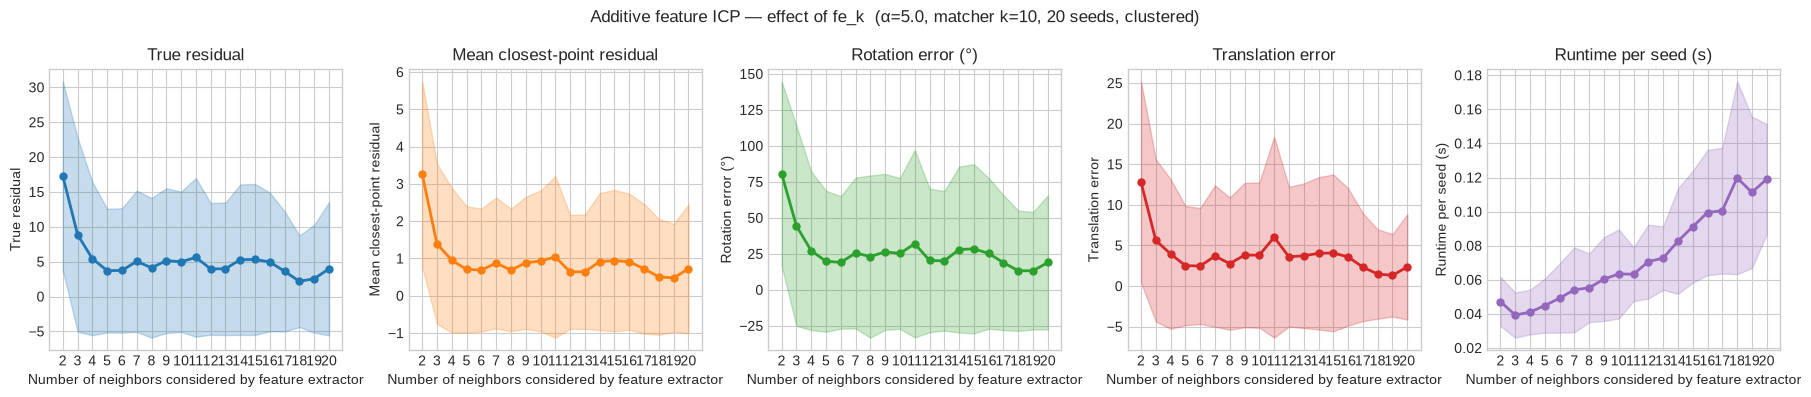

In [10]:
true_residuals = np.array([r.mean_true_residuals for r in sweep_results])
residuals = np.array([r.mean_closest_point_residuals for r in sweep_results])
rotation_errors = np.array([r.rotation_errors for r in sweep_results])
translation_errors = np.array([r.translation_errors for r in sweep_results])
durations_s = np.array([r.durations_s for r in sweep_results])
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
ErrorMetricsVisualizer.plot_parameter_sweep(
    axes=axes,
    data_per_metric=[true_residuals, residuals, rotation_errors, translation_errors, durations_s],
    y_labels=['True residual', 'Mean closest-point residual', 'Rotation error (°)', 'Translation error', 'Runtime per seed (s)'],
    x=FE_K_VALUES,
    x_label='Number of neighbors considered by feature extractor',
)

fig.suptitle(
    f'Additive feature ICP — effect of fe_k  '
    f'(α={ALPHA}, matcher k={K}, {N_SEEDS} seeds, {GEN_KWARGS["style"]})'
)
plt.tight_layout()
plt.savefig('../results/7_feature_icp_comparison_k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()